<a href="https://colab.research.google.com/github/marianamalagon11/PTIA_LAB1_DT/blob/main/DT_lab_ignaciocastillo_marianamalagon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np


In [ ]:
import matplotlib.pyplot as plt


# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## ARBOLES DE DECISIÓN
## LABORATORIO 1/4
## Integrantes: Ignacio Castillo y Mariana Malagón
## Grupo 4

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando árboles de decisión
2. Implementar árboles de decisión
3. Apropiar un framework para árboles de decisión (*scikit-learn*)
4. Conocer una librería para procesamiento de datos simbólicos (*python pandas DataFrame*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Este laboratorio se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
Incluyan en un archivo *.zip* los archivos correspondientes al laboratorio.

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “DT-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# **PARTE I. IMPLEMENTACIÓN DE ÁRBOLES DE DECISIÓN**
Para este apartado se van a implementar un árbol de decisión, en este caso usando como medida la entropia.

*La idea de los árboles de decisión fue desarrollada paulatinamiente. El pionero más reconocido es Ross Quinlan, quien propuso en 1986 el algoritmo ID3 (Iterative Dichotomiser 3) en el artículo [Induction of decision trees](https://link.springer.com/article/10.1007/BF00116251). Este algoritmo marcó un hito en la construcción automática de árboles de decisión a partir de datos.*

## I.A. IMPLEMENTACIÓN DE UN ÁRBOL DE DECISIÓN

Implementar un árbol de decisión; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades:**

*   Tarea: **Clasificación binaria**
*   Características: **Categóricas**
*   Criterio de selección: **Ganancia de información**
*   Métrica para evaluación : **F1 SCORE**

<div>
<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2020/09/Precision-vs-Recall-in-Machine-Learning.webp" width="350"/>
</div>

> **Formulas**

*   Impureza : **Entropía: H**

*   Ganancia de información: **IG(D,A)**

*   Impureza de Arbol: **Impurity(V\*)**







## Paso 1. Criterios de selección de atributos
Las impurezas en árboles de decision miden cuán homogéneas o heterogéneas son las clases dentro de un conjunto de datos ***en un nodo del árbol***. La métrica de impureza determina cómo dividir los datos en cada nodo.
Los principales métodos de evaluación de impureza son: **entropía** e **indice gini**.

*Incluyan las formulas de los dos criterios de selección y comparelos considerando criterios como sensibilidad al desbalance de clases y eficiencia computacional*

---
**Entropia:**

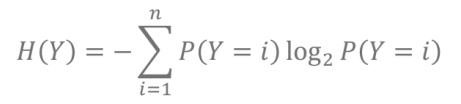

---
**Gini**

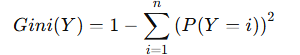

---
**Comparación**
Ambos son medidas de impureza que se usan en árboles de decisión para elegir al mejor atributo de división.
Las dos evalúan qué tan mezcladas están las clases en un nodo, pero la diferencia es su fórmula y su comportamiento.

*Sensibilidad al desbalance de clases:*

La entropía es más sensible a cambios en probabilidades pequeñas, por el algoritmo que usan , en cambio el índice de Gini es un poco menos sensible ante pqueñas variaciones en clases poco representadas.

*Eficiencia computacional:*

El índice de Gini solo requiere multiplicaciones y sumas, lo que lo hace más efeiciente, y la entropía requiere logaritmos, lo que incrementea el costo computacional.

## Paso 2. Ganancia de una característica e impureza del árbol
Los otros dos conceptos de fundamentan los árboles de decisión son la **ganancia de información** y la **impureza *de un arbol***.

**Ganancia:**

*Propósito:*

La ganancia de información mide cuánto disminuye la impureza de un conjunto de datos después de que fue dividido según una característica elegida.
Selecciona el atributo que mejor separa las clases, o sea el que produce nodos más puros luego de haber sido dividido.
Termina escogiendo la característica que maximiza a ganancia.

*Fórmula:*

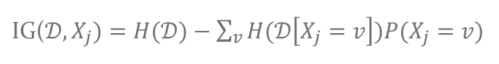

Donde H(D) es la entropía antes de dividir, H(Xj | v) es  la proporción de eventos con valor v.

---
**Impureza**

*Propósito*: Mide que tan homogéneos son los nodos hoja del árbol completo. Un árbol tiene menor impureza cuando sus hojas contienen ejemplos de una sola clase.

*Fórmula:*

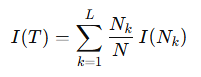


Donde L es el número de nodos de hoja, Nk es el número de muestras en la hoja k, N es el total de muestras y I(Nk) es la impureza del nodo.




## Paso 3. Implementación del código base para un árbol de decisión

### Librería necesaria

In [ ]:
import pandas as pd
from abc import ABC, abstractmethod

### Funciones base: métrica y criterio

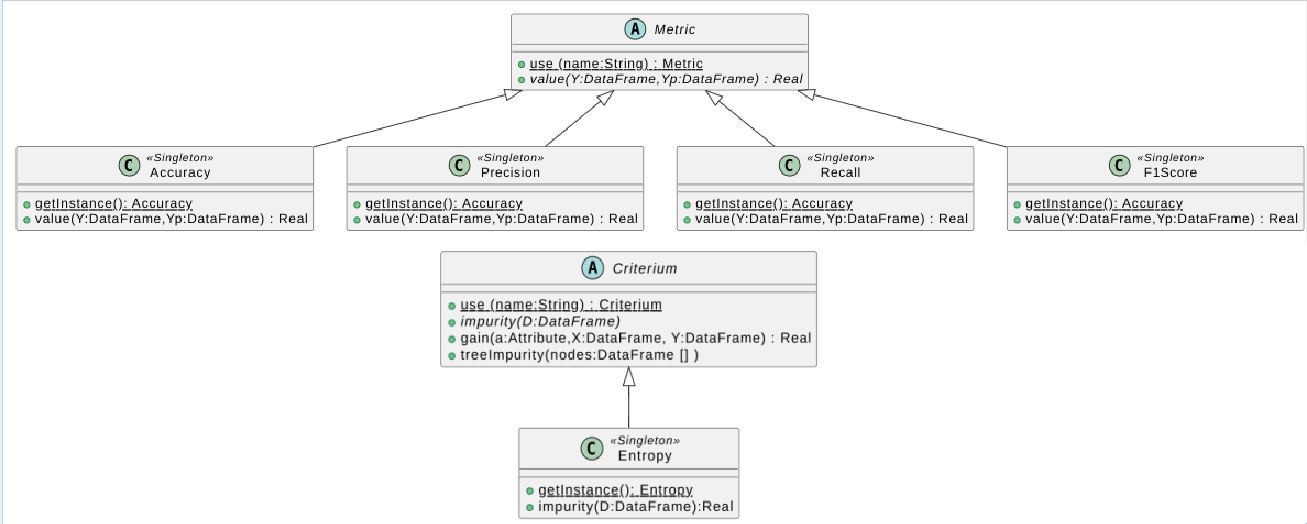

###Métrica

In [ ]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier metrica
  Representa una metrica de desempeño P para evaluar una tarea T
  """
  _instances = {}
  @classmethod
  def use(cls,name: str):
    """ obtiene metrica (OBJ) a partir del nombre
    Args:
      name  : nombre esperado de la metrica
    Returns:
       objeto metrica
    """
    name = name.lower()
    metrics = {
        "accuracy": Accuracy,
        "precision": Precision,
        "recall": Recall,
        "f1": F1Score
    }
    if name in metrics:
      return metrics[name]()


  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame)->float:
    """ computa el desempeño P
    Args:
      Y   s de salidas esperadas (etiquetadas)
      Yp  : valores de salidas obtenidas
    Return:
      valor del desempeño
    """
    pass

In [ ]:
class Accuracy(Metric):
  """
  Calcula la exactitud del modelo:
  Accuracy = (Número de predicciones correctas) / (Total de predicciones)
  """

  _instance = None

  def __new__(cls):
    """
    Implementa patrón Singleton.
    Garantiza que solo exista una instancia de la clase.
    """
    if cls._instance is None:
      cls._instance = super(Accuracy, cls).__new__(cls)
    return cls._instance

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """
    Calcula la proporción de aciertos sobre el total de ejemplos.

    Returns:
        float: Exactitud del modelo.
    """
    correct = (Y.values.flatten() == Yp.values.flatten()).sum()
    total = len(Y)
    return correct / total

  #para puntos posteriores:
  def compute(self, Y, Yp):
          import numpy as np

          Y = np.array(Y)
          Yp = np.array(Yp)

          return np.sum(Y == Yp) / len(Y)

In [ ]:
class Precision(Metric):
  """
  Calcula la precisión del modelo:
  Precision = TP / (TP + FP)
  """

  _instance = None

  def __new__(cls):
    """
    Implementa patrón Singleton.
    """
    if cls._instance is None:
      cls._instance = super(Precision, cls).__new__(cls)
    return cls._instance

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """
    Calcula la proporción de verdaderos positivos
    respecto a todas las predicciones positivas.
    """
    Y = Y.values.flatten()
    Yp = Yp.values.flatten()

    TP = ((Y == 1) & (Yp == 1)).sum()
    FP = ((Y == 0) & (Yp == 1)).sum()

    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

In [ ]:
class Recall(Metric):
  """
  Calcula la exhaustividad (recall):
  Recall = TP / (TP + FN)
  """

  _instance = None

  def __new__(cls):
    """
    Implementa patrón Singleton.
    """
    if cls._instance is None:
      cls._instance = super(Recall, cls).__new__(cls)
    return cls._instance

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """
    Calcula la proporción de verdaderos positivos
    respecto a los positivos reales.
    """
    Y = Y.values.flatten()
    Yp = Yp.values.flatten()

    TP = ((Y == 1) & (Yp == 1)).sum()
    FN = ((Y == 1) & (Yp == 0)).sum()

    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

In [ ]:
class F1Score(Metric):
  """
  Calcula la media armónica entre Precisión y Recall:

  F1 = 2 * (Precision * Recall) / (Precision + Recall)
  """

  _instance = None

  def __new__(cls):
    """
    Implementa patrón Singleton.
    """
    if cls._instance is None:
      cls._instance = super(F1Score, cls).__new__(cls)
    return cls._instance

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """
    Calcula el F1-score combinando precisión y recall.
    """
    precision = Precision().value(Y, Yp)
    recall = Recall().value(Y, Yp)

    return (2 * precision * recall) / (precision + recall) \
           if (precision + recall) > 0 else 0.0

In [ ]:
#casos de preba de los métodos implementados
Y  = pd.DataFrame([1, 0, 1, 1, 0, 1])
Yp = pd.DataFrame([1, 0, 0, 1, 0, 1])

print("Accuracy:", Metric.use("accuracy").value(Y, Yp))
print("Precision:", Metric.use("precision").value(Y, Yp))
print("Recall:", Metric.use("recall").value(Y, Yp))
print("F1:", Metric.use("f1").value(Y, Yp))

Accuracy: 0.8333333333333334
Precision: 1.0
Recall: 0.75
F1: 0.8571428571428571


Los resultados muestran que el modelo tiene alta precisión (no genera falsos positivos), pero presenta un falso negativo, lo que reduce el recall. El F1-score refleja el balance entre ambas métricas.

###Criterio

In [ ]:
class Criterium(ABC):
  """ Abstracta: Define el criterio para seleccionar y dar prioridad a los atributos
  Representa la impureza
  """
  @classmethod
  def use(cls, name: str):
    """ obtiene criterio de selección (OBJ) a partir del nombre
    Args:
      name  : nombre esperado del criterio
    Returns:
      objeto criterio de selección
    """
    name = name.lower()

    if name == "entropy":
      return Entropy()
    else:
      raise ValueError("Criterio no soportado")

  def impurity(self, V: pd.DataFrame) -> float:
    """ computa la impureza en un nodo/vértice
    Args:
      V    : ejemplares para una característica
    Returns:
       valor de la impureza del nodo
    """
    pass

  def gain(self, a: str, X: pd.DataFrame, Y: [pd.DataFrame]) -> float:
    """ computa la ganancia de información de un nodo con 1 o más hijos
    Args:
      a  : atributo/característica a evaluar
      X : ejemplares / valores de entrada
      Y : valores de salida esperados
    Returns:
      valor de la ganancia de información
    """
    pass

  def treeImpurity(self, nodes: [pd.DataFrame]) -> float:
    """ computa la impureza de todo un arbol
    Args:
      nodes    : datos de cada uno de los nodos del arbol
    Returns:
      valor de la impureza del arbol
    """
    pass

In [ ]:
class Entropy(Criterium):
    """
    Criterio de selección basado en Entropía.
    Se utiliza para medir la impureza de un nodo en árboles de decisión.
    """

    def __new__(cls):
        return super(Entropy, cls).__new__(cls)

    def impurity(self, V: pd.Series) -> float:
        """
        Calcula la entropía de un conjunto de etiquetas.

        Args:
            V (pd.Series): vector de clases (etiquetas)

        Returns:
            float: valor de la entropía
        """
        values, counts = np.unique(V, return_counts=True)
        probabilities = counts / counts.sum()

        entropy = -np.sum([
            p * np.log2(p) if p > 0 else 0
            for p in probabilities
        ])

        return entropy

    def gain(self, a: str, X: pd.DataFrame, Y: pd.Series) -> float:
        """
        Calcula la ganancia de información de un atributo.

        Args:
            a (str): atributo a evaluar
            X (pd.DataFrame): datos de entrada
            Y (pd.Series): etiquetas

        Returns:
            float: ganancia de información
        """
        # Entropía inicial del nodo padre
        parent_entropy = self.impurity(Y)

        # Valores únicos del atributo
        values = X[a].unique()

        weighted_entropy = 0

        for v in values:
            mask = X[a] == v
            Y_subset = Y[mask]

            weight = len(Y_subset) / len(Y)
            weighted_entropy += weight * self.impurity(Y_subset)

        # Ganancia = Entropía padre - entropía ponderada hijos
        return parent_entropy - weighted_entropy

    def treeImpurity(self, nodes: list) -> float:
        """
        Calcula la impureza total de un árbol.

        Args:
            nodes (list): lista de nodos (cada nodo es un pd.Series con etiquetas)

        Returns:
            float: impureza promedio ponderada del árbol
        """
        total_samples = sum(len(node) for node in nodes)

        total_impurity = 0
        for node in nodes:
            weight = len(node) / total_samples
            total_impurity += weight * self.impurity(node)

        return total_impurity

    #para puntos posteriores:
    def compute(self, Y):
        import numpy as np

        values, counts = np.unique(Y, return_counts=True)
        probabilities = counts / len(Y)

        entropy = 0
        for p in probabilities:
            if p > 0:
                entropy -= p * np.log2(p)

        return entropy

In [ ]:
# Adicione los casos de prueba de los métodos implementados
criterion = Criterium.use("entropy")

print(" PRUEBAS impurity()")
# nodo puro
Y1 = pd.Series([1, 1, 1, 1])
print("Impurity nodo puro:", criterion.impurity(Y1))  # se espera de resultado 0

# distribución 50 50
Y2 = pd.Series([0, 0, 1, 1])
print("Impurity 50-50:", criterion.impurity(Y2))  # se espera de resultado 1

# distribución desbalanceada
Y3 = pd.Series([0, 0, 0, 1])
print("Impurity desbalanceado:", criterion.impurity(Y3))  # se espera aproxx 0.8113


print("\n PRUEBAS gain()")

X = pd.DataFrame({
    "Color": ["Rojo", "Rojo", "Azul", "Azul"],
    "Forma": ["Cuadrado", "Circulo", "Cuadrado", "Circulo"]
})

Y = pd.Series([0, 0, 1, 1])

print("Gain(Color):", criterion.gain("Color", X, Y))  # se espera de resultado 1
print("Gain(Forma):", criterion.gain("Forma", X, Y))  # se espera de resultado 0


print("\nPRUEBAS treeImpurity()")

node1 = pd.Series([0, 0])
node2 = pd.Series([1, 1])

print("Tree Impurity (nodos puros):",
      criterion.treeImpurity([node1, node2]))  # se espera de resultado 0

node3 = pd.Series([0, 1])
node4 = pd.Series([0, 1])

print("Tree Impurity (nodos mixtos):",
      criterion.treeImpurity([node3, node4]))  # se espera de resultado 1

 PRUEBAS impurity()
Impurity nodo puro: -0.0
Impurity 50-50: 1.0
Impurity desbalanceado: 0.8112781244591328

 PRUEBAS gain()
Gain(Color): 1.0
Gain(Forma): 0.0

PRUEBAS treeImpurity()
Tree Impurity (nodos puros): 0.0
Tree Impurity (nodos mixtos): 1.0


Los resultados obtenidos coinciden con los valores teóricos esperados, validando el correcto funcionamiento del criterio de entropía y la ganancia de información en la implementación realizada.

### Árbol de decisión
Para la implementación sigan las decisiones de diseño presentadas en el diagrama de clases. Pueden incluir los métodos y clases adicionales que requieran.

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (1xc) o todos los ejemplos (mxc)
  - **y**, **Y** : salidas reales. Un ejemplo (1xc) o todos los ejemplos(mxc)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (1xc) o todos los ejemplos(cxm)


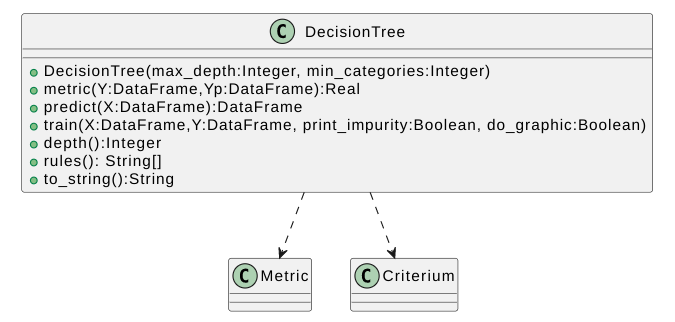

Haremos una clase auxiliar de nodo:

In [ ]:
class Node:
    """
    Representa un nodo del árbol de decisión.
    """

    def __init__(self, feature=None, label=None, depth=0):
        self.feature = feature
        self.label = label
        self.children = {}
        self.depth = depth
        self.is_leaf = False
        self.prediction = None

In [ ]:
class DecisionTree:
  """ Representa un árbol de decisión
  """

  def __init__(self, max_depth: int, min_categories: int):
    """ inicializar la clase de árbol de decisión.
    Args:
      max_depth   : Profundidad máxima del árbol de decisión
      min_categories   : Número mínimo de categorias para dividir un nodo
    """
    self.max_depth = max_depth
    self.min_categories = min_categories
    self.root = None
    self.criterion = Criterium.use("entropy")
    self.metric_used = Metric.use("accuracy")
    self.impurities = []

  def metric(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ computa la metrica del modelo a partir de los ejemplares comparando las salidas
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp  : valores de salidas obtenidas
    Return:
       desempeño del modelo para ejemplares
    """
    return self.metric_used.compute(Y, Yp)

  def predict(self, X: pd.DataFrame) -> pd.DataFrame:
    """ computa una serie de entradas a traves del arbol generando una predicción
    Args:
      X    : valores de características (entradas)
    Return:
     valores de salidas obtenidas
    """
    predictions = []

    for _, row in X.iterrows():
      node = self.root

      while not node.is_leaf:
        value = row[node.feature]
        if value in node.children:
          node = node.children[value]
        else:
          break

      predictions.append(node.prediction)

    return pd.DataFrame(predictions)

  def train(self, X: pd.DataFrame, Y: pd.DataFrame, print_impurity: bool, do_graphic: bool):
    """ construye y entrena el árbol de decisión a partir de unos ejemplares.
    Args:
      X  : valores de características - conjunto de entrenamiento
      Y  : valores de salidas esperadas - conjunto de entrenamiento
      print_impurity : mostrar la impureza del arbol por iteración
      do_graphic: graficar las impurezas por iteración
    """
    self.impurities = []
    self.root = self._build_tree(X, Y, depth=0)

    if print_impurity:
      print("Impurezas por nodo:")
      for i, imp in enumerate(self.impurities):
        print(f"Iteración {i}: {imp}")

    if do_graphic and len(self.impurities) > 0:
      plt.figure()
      plt.plot(self.impurities)
      plt.title("Impureza por iteración")
      plt.xlabel("Iteración")
      plt.ylabel("Impureza")
      plt.show()

  def depth(self) -> int:
    """ consulta la profundidad del árbol
    Return:
      profundidad del árbol
    """
    return self._compute_depth(self.root)

  def rules(self) -> [str]:
    """ consultar las reglas del árbol
    Return:
      reglas del árbol de decisión
    """
    rules_list = []
    self._extract_rules(self.root, "", rules_list)
    return rules_list

  def to_string(self) -> str:
    """ consultar la estructura del arbol
    Return:
      estructura del árbol
    """
    return self._tree_to_string(self.root, "")

  # para orden y no tener funciones tan largas añadimos algunos métodos privados necesarios para nuestra implementación

  def _build_tree(self, X, Y, depth):

    node = Node()
    impurity = self.criterion.compute(Y)
    self.impurities.append(impurity)

    if (
      depth >= self.max_depth or
      len(Y.unique()) == 1 or
      X.empty
    ):
      node.is_leaf = True
      node.prediction = Y.mode()[0]
      return node

    best_feature = None
    best_gain = -1

    for feature in X.columns:
      gain = self._information_gain(X[feature], Y)
      if gain > best_gain:
        best_gain = gain
        best_feature = feature

    if best_feature is None:
      node.is_leaf = True
      node.prediction = Y.mode()[0]
      return node

    node.feature = best_feature
    node.children = {}

    for category in X[best_feature].unique():
      mask = X[best_feature] == category
      X_sub = X[mask].drop(columns=[best_feature])
      Y_sub = Y[mask]

      if len(Y_sub) < self.min_categories:
        child = Node()
        child.is_leaf = True
        child.prediction = Y.mode()[0]
        node.children[category] = child
      else:
        node.children[category] = self._build_tree(
          X_sub, Y_sub, depth + 1
        )

    return node

  def _information_gain(self, feature_column, Y):

    total_entropy = self.criterion.compute(Y)
    values = feature_column.unique()
    weighted_entropy = 0

    for v in values:
      Y_sub = Y[feature_column == v]
      weight = len(Y_sub) / len(Y)
      weighted_entropy += weight * self.criterion.compute(Y_sub)

    return total_entropy - weighted_entropy

  def _compute_depth(self, node):
    if node is None or node.is_leaf:
      return 0
    return 1 + max(self._compute_depth(child) for child in node.children.values())

  def _extract_rules(self, node, path, rules_list):

    if node.is_leaf:
      rules_list.append(f"{path} THEN {node.prediction}")
      return

    for value, child in node.children.items():
      new_path = f"{path} IF {node.feature} == {value}"
      self._extract_rules(child, new_path, rules_list)

  def _tree_to_string(self, node, indent):

    if node.is_leaf:
      return indent + f"Leaf -> {node.prediction}\n"

    text = indent + f"{node.feature}\n"

    for value, child in node.children.items():
      text += indent + f" ├─ {value}:\n"
      text += self._tree_to_string(child, indent + "   ")

    return text

In [ ]:
# Como primer caso de prueba entrene un árbol para calcular el operador lógico and. Explique los resultados.
X_and = pd.DataFrame({
    "A": [0,0,1,1],
    "B": [0,1,0,1]
})

Y_and = pd.DataFrame({
    "Y": [0,0,0,1]
})

#entrenamiento
tree_and = DecisionTree(max_depth=3, min_categories=1)
tree_and.train(X_and, Y_and["Y"], print_impurity=True, do_graphic=False)

Yp_and = tree_and.predict(X_and)

print("Predicciones:")
print(Yp_and)

print("Accuracy:", tree_and.metric(Y_and["Y"], Yp_and[0]))
print("Profundidad:", tree_and.depth())
print("Reglas:")
print(tree_and.rules())

Impurezas por nodo:
Iteración 0: 0.8112781244591328
Iteración 1: 0.0
Iteración 2: 1.0
Iteración 3: 0.0
Iteración 4: 0.0
Predicciones:
   0
0  0
1  0
2  0
3  1
Accuracy: 1.0
Profundidad: 2
Reglas:
[' IF A == 0 THEN 0', ' IF A == 1 IF B == 0 THEN 0', ' IF A == 1 IF B == 1 THEN 1']


Explicación de resultados:
El árbol logró aprender perfectamente el operador lógico AND, alcanzando una exactitud del 100%. La estructura generada tiene profundidad 2, ya que primero divide por la variable A y luego por B cuando A = 1. Las reglas obtenidas corresponden exactamente a la tabla de verdad del operador AND. Las impurezas disminuyen hasta cero en los nodos hoja, indicando particiones puras.

In [ ]:
# Como segundo caso de prueba entrene un árbol para calcular el operador lógico or. Explique los resultados.
X_or = pd.DataFrame({
    "A": [0,0,1,1],
    "B": [0,1,0,1]
})

Y_or = pd.DataFrame({
    "Y": [0,1,1,1]
})

#entrenamiento:
tree_or = DecisionTree(max_depth=3, min_categories=1)
tree_or.train(X_or, Y_or["Y"], print_impurity=True, do_graphic=False)

Yp_or = tree_or.predict(X_or)

print("Predicciones:")
print(Yp_or)

print("Accuracy:", tree_or.metric(Y_or["Y"], Yp_or[0]))
print("Profundidad:", tree_or.depth())
print("Reglas:")
print(tree_or.rules())

Impurezas por nodo:
Iteración 0: 0.8112781244591328
Iteración 1: 1.0
Iteración 2: 0.0
Iteración 3: 0.0
Iteración 4: 0.0
Predicciones:
   0
0  0
1  1
2  1
3  1
Accuracy: 1.0
Profundidad: 2
Reglas:
[' IF A == 0 IF B == 0 THEN 0', ' IF A == 0 IF B == 1 THEN 1', ' IF A == 1 THEN 1']


Explicación resultados: En el caso del operador OR, el árbol de decisión logró una exactitud del 100%, lo que indica que aprendió correctamente la relación entre las variables.

La impureza inicial fue 0.8112... y, después de las divisiones, los nodos hoja alcanzaron impureza 0.0, lo que significa que quedaron completamente puros. La profundidad obtenida fue 2, ya que el árbol primero divide por la variable A y, cuando A = 0, divide por B.

Las reglas generadas coinciden exactamente con la tabla de verdad del operador OR, confirmando el correcto funcionamiento del modelo.

In [ ]:
# Como tercer caso de prueba entrene un árbol para calcular el operador lógico xor. Explique los resultados.
X_xor = pd.DataFrame({
    "A": [0,0,1,1],
    "B": [0,1,0,1]
})

Y_xor = pd.DataFrame({
    "Y": [0,1,1,0]
})

#entrenamiento:
tree_xor = DecisionTree(max_depth=3, min_categories=1)
tree_xor.train(X_xor, Y_xor["Y"], print_impurity=True, do_graphic=False)

Yp_xor = tree_xor.predict(X_xor)

print("Predicciones:")
print(Yp_xor)

print("Accuracy:", tree_xor.metric(Y_xor["Y"], Yp_xor[0]))
print("Profundidad:", tree_xor.depth())
print("Reglas:")
print(tree_xor.rules())

Impurezas por nodo:
Iteración 0: 1.0
Iteración 1: 1.0
Iteración 2: 0.0
Iteración 3: 0.0
Iteración 4: 1.0
Iteración 5: 0.0
Iteración 6: 0.0
Predicciones:
   0
0  0
1  1
2  1
3  0
Accuracy: 1.0
Profundidad: 2
Reglas:
[' IF A == 0 IF B == 0 THEN 0', ' IF A == 0 IF B == 1 THEN 1', ' IF A == 1 IF B == 0 THEN 1', ' IF A == 1 IF B == 1 THEN 0']


Explicación resultados:En el caso del operador XOR, el árbol también alcanzó una exactitud del 100%. La impureza inicial fue 1.0, reflejando máxima incertidumbre, ya que las clases están balanceadas.

A diferencia de AND y OR, se requieren divisiones adicionales para lograr nodos puros, lo que explica la presencia de impurezas intermedias de 1.0. La profundidad final fue 2, suficiente para representar correctamente la relación no lineal de XOR.

Las reglas obtenidas coinciden exactamente con su tabla de verdad, demostrando que el árbol puede modelar relaciones no lineales mediante divisiones sucesivas.

In [ ]:
# Como último caso de prueba entrene un árbol para el dataset propuesto por su profesor.
# Tratando de importar siguiendo los pasos de la página no sirvió.
# Entonces lo haremos de la siguiente manera:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/voting-records/house-votes-84.data"

columns = [
    "party",
    "handicapped-infants",
    "water-project-cost-sharing",
    "adoption-of-the-budget-resolution",
    "physician-fee-freeze",
    "el-salvador-aid",
    "religious-groups-in-schools",
    "anti-satellite-test-ban",
    "aid-to-nicaraguan-contras",
    "mx-missile",
    "immigration",
    "synfuels-corporation-cutback",
    "education-spending",
    "superfund-right-to-sue",
    "crime",
    "duty-free-exports",
    "export-administration-act-south-africa"
]

df = pd.read_csv(url, header=None, names=columns)

df.head()

#separamos X y Y
Y = df["party"] #acá es lo que queremos predecir
X = df.drop(columns=["party"]) #acá los votos que vendrían siendo las características

# reemplazar valores faltantes
X = X.replace("?", "no hay voto")

#verificamos si si importó
print(X.head())
print(Y.head())


  handicapped-infants water-project-cost-sharing  \
0                   n                          y   
1                   n                          y   
2         no hay voto                          y   
3                   n                          y   
4                   y                          y   

  adoption-of-the-budget-resolution physician-fee-freeze el-salvador-aid  \
0                                 n                    y               y   
1                                 n                    y               y   
2                                 y          no hay voto               y   
3                                 y                    n     no hay voto   
4                                 y                    n               y   

  religious-groups-in-schools anti-satellite-test-ban  \
0                           y                       n   
1                           y                       n   
2                           y                       n   
3 

In [ ]:
#Use 80% para entrenamiento y 20% para pruebas. Explique los resultados.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Convertir variables categóricas a numéricas
X = pd.get_dummies(X)

# Dividir 80% entrenamiento - 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,   # 20% prueba
    random_state=42,
    stratify=Y
)

# Crear modelo
model = DecisionTreeClassifier(random_state=42)

# Entrenar
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_test)

# Evaluar
accuracy = accuracy_score(y_test, y_pred)

print("Precisión del modelo:", accuracy)
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.9425287356321839

Reporte de clasificación:

              precision    recall  f1-score   support

    democrat       0.96      0.94      0.95        53
  republican       0.91      0.94      0.93        34

    accuracy                           0.94        87
   macro avg       0.94      0.94      0.94        87
weighted avg       0.94      0.94      0.94        87



Explicación de resultados:Se dividió el dataset en 80% para entrenamiento y 20% para pruebas, obteniendo 87 registros para evaluación.
El Árbol de Decisión alcanzó una precisión del 94.25%, lo que indica que el modelo clasifica correctamente la mayoría de los congresistas según su patrón de votación.

Para la clase “democrat” se obtuvo un F1-score de 0.95 y para “republican” un F1-score de 0.93, lo que demuestra un desempeño equilibrado en ambas clases.

Estos resultados evidencian que existe una fuerte relación entre el comportamiento de votación y la afiliación política, permitiendo que el modelo identifique correctamente el partido con alta exactitud.


# **PARTE II. USO DE FRAMEWORK PARA ARBOLES DE DECISIÓN**

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintos algoritmos basados en árboles de deciisón. En este caso será **scikit-learn**

**scikit-learn** es una biblioteca de Python que facilita la implementación de algoritmos de aprendizaje automático. Es ampliamente usada en la industria por su simplicidad, buena documentación y eficiencia.

**scikit-learn** ofrece diferentes estrategias de aprendizaje basadas en árboles; entre ellas las que exploraremos en este laboratorio.
- [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/search.html?q=RandomForestClassifier)
- [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adecuada (f1_score) y establecer un umbral de desempeño.


*Incluyan la respuesta*

Problema

El objetivo es clasificar el partido político (democrat o republican) de un congresista a partir de su patrón de votación en distintos proyectos de ley.

Es un problema de: Clasificación supervisada binaria.

Para esto elegimos F1-score porque:
Combina precisión (precision) y exhaustividad (recall).
Es adecuada cuando queremos equilibrio entre ambas clases.
Penaliza tanto falsos positivos como falsos negativos.

Umbral de desempeño:
Un umbral aceptable para nosotros es

F1-score ≥ 0.90

Debido a que el dataset tiene patrones de votación claramente diferenciados entre partidos.

##Paso 2: Explorar y preparar los datos
Para comprender la naturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, cuando se requiera, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

In [ ]:
#Analizar los datos
# ver primeras filas
print(df.head())

# ver Info general
print(df.info())

# distribución de clases
print(df["party"].value_counts())

# ver valores nulos
print(df.isnull().sum())

        party handicapped-infants water-project-cost-sharing  \
0  republican                   n                          y   
1  republican                   n                          y   
2    democrat                   ?                          y   
3    democrat                   n                          y   
4    democrat                   y                          y   

  adoption-of-the-budget-resolution physician-fee-freeze el-salvador-aid  \
0                                 n                    y               y   
1                                 n                    y               y   
2                                 y                    ?               y   
3                                 y                    n               ?   
4                                 y                    n               y   

  religious-groups-in-schools anti-satellite-test-ban  \
0                           y                       n   
1                           y               

*Incluyan observaciones*

El dataset contiene 435 registros correspondientes a congresistas, con 16 variables predictoras y una variable objetivo (“party”).

La variable objetivo presenta dos clases: democrat (267 registros) y republican (168 registros), evidenciando un ligero desbalance de clases, aunque no significativo.

No se encontraron valores nulos explícitos; sin embargo, existen valores faltantes representados con el símbolo “?”, los cuales requieren tratamiento previo al entrenamiento.

Todas las variables son categóricas, por lo que fue necesario aplicar codificación one-hot(convertir variable categóricas (letras)en números, para que sean trabajables) para permitir su uso en modelos de aprendizaje automático.

Dado que no existen variables numéricas continuas, no fue necesario aplicar técnicas de normalización o estandarización.

In [ ]:
#Preparar los datos separandolos en entrenamiento, validación y pruebas.
from sklearn.model_selection import train_test_split

# 1. Separar variables
Y = df["party"]
X = df.drop(columns=["party"])

# 2. Manejo de valores faltantes
X = X.replace("?", "unknown")

# 3. Codificación One-Hot
X = pd.get_dummies(X)

# 4. División 70% - 10% - 20%

# Primero separar 20% para pruebas
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,        # 20% test
    random_state=42,
    stratify=Y
)

# Ahora separar 10% validación y 70% entrenamiento
# 10% del total equivale a 0.125 del 80% restante
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,      # 10% del total
    random_state=42,
    stratify=y_temp
)

# 5. Verificar tamaños
print("Entrenamiento:", len(X_train))
print("Validación:", len(X_val))
print("Pruebas:", len(X_test))

Entrenamiento: 304
Validación: 44
Pruebas: 87


Los datos fueron preparados reemplazando los valores faltantes representados como “?” y aplicando codificación one-hot a las variables categóricas.
Posteriormente, el dataset fue dividido en 70% para entrenamiento, 10% para validación y 20% para pruebas, utilizando muestreo estratificado para mantener la proporción de clases en cada subconjunto.
El conjunto de entrenamiento se utilizará para ajustar los modelos, el de validación para comparar su desempeño y el de prueba para evaluar el rendimiento final.

##Paso 3: Desarrollar el modelo
La estrategia que vamos a seguir es desarrollar tres modelos diferentes y escoger entre ellos el mejor modelo para probarlo.
- Los tres modelos se entrenan con *train*
- El mejor modelo se selecciona con *dev*
- El modelo seleccionado se prueba con *test*

###Paso 3.1: Entrenar los modelos candidatos

#### Paso 3.1.1: Entrenar un árbol de decisión

1. Se crea una instancia de la clase `DecisionTreeClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score

# 1. Crear instancia del árbol de decisión
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Entrenar con datos de entrenamiento
dt_model.fit(X_train, y_train)

# 3. Calcular F1 en entrenamiento
y_pred_train_dt = dt_model.predict(X_train)
f1_train_dt = f1_score(y_train, y_pred_train_dt, pos_label='democrat')
acc_train_dt = accuracy_score(y_train, y_pred_train_dt)

print("Árbol de Decisión (Entrenamiento)")
print(f"F1-score (train):    {f1_train_dt:.4f}")
print(f"Exactitud (train):   {acc_train_dt:.4f}")
print(f"Altura del árbol:    {dt_model.get_depth()}")
print(f"Número de hojas:     {dt_model.get_n_leaves()}")
print(f"Número de reglas:    {dt_model.get_n_leaves()} (una por hoja)")
# Impureza ponderada del árbol
impurity_dt = dt_model.tree_.impurity
n_node_samples = dt_model.tree_.n_node_samples
weighted_impurity_dt = (impurity_dt * n_node_samples).sum() / n_node_samples[0]
print(f"Impureza ponderada:  {weighted_impurity_dt:.4f}")

Árbol de Decisión (Entrenamiento)
F1-score (train):    1.0000
Exactitud (train):   1.0000
Altura del árbol:    6
Número de hojas:     20
Número de reglas:    20 (una por hoja)
Impureza ponderada:  0.7109


#### Paso 3.1.2: Entrenar un bosque aleatorio

1. Se crea una instancia de la clase `RandomForestClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)

In [ ]:
# 1. Crear instancia del bosque aleatorio
rf_model = RandomForestClassifier(random_state=42)

# 2. Entrenar
rf_model.fit(X_train, y_train)

# 3. Calcular F1 en entrenamiento
y_pred_train_rf = rf_model.predict(X_train)
f1_train_rf = f1_score(y_train, y_pred_train_rf, pos_label='democrat')
acc_train_rf = accuracy_score(y_train, y_pred_train_rf)

# Calcular altura y hojas promedio
depths_rf = [estimator.get_depth() for estimator in rf_model.estimators_]
leaves_rf = [estimator.get_n_leaves() for estimator in rf_model.estimators_]
avg_depth_rf = sum(depths_rf) / len(depths_rf)
avg_leaves_rf = sum(leaves_rf) / len(leaves_rf)

print("Bosque Aleatorio (Entrenamiento)")
print(f"F1-score (train):        {f1_train_rf:.4f}")
print(f"Exactitud (train):       {acc_train_rf:.4f}")
print(f"Altura promedio:         {avg_depth_rf:.2f}")
print(f"Hojas promedio:          {avg_leaves_rf:.2f}")
print(f"N° estimadores:          {rf_model.n_estimators}")

# Impureza ponderada promedio
weighted_impurities = []
for est in rf_model.estimators_:
    imp = est.tree_.impurity
    ns = est.tree_.n_node_samples
    weighted_impurities.append((imp * ns).sum() / ns[0])
avg_impurity_rf = sum(weighted_impurities) / len(weighted_impurities)
print(f"Impureza ponderada prom: {avg_impurity_rf:.4f}")

Bosque Aleatorio (Entrenamiento)
F1-score (train):        1.0000
Exactitud (train):       1.0000
Altura promedio:         8.91
Hojas promedio:          26.55
N° estimadores:          100
Impureza ponderada prom: 1.0915


#### Paso 3.1.3: Entrenar un bosque con potenciación de gradiente
1. Se crea una instancia de la clase `GradientBoostingClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)

In [ ]:
# 1. Crear instancia del Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)

# 2. Entrenar
gb_model.fit(X_train, y_train)

# 3. Calcular F1 en entrenamiento
y_pred_train_gb = gb_model.predict(X_train)
f1_train_gb = f1_score(y_train, y_pred_train_gb, pos_label='democrat')
acc_train_gb = accuracy_score(y_train, y_pred_train_gb)

# Calcular altura y hojas promedio (estructura de árboles base)
depths_gb = [est[0].get_depth() for est in gb_model.estimators_]
leaves_gb = [est[0].get_n_leaves() for est in gb_model.estimators_]
avg_depth_gb = sum(depths_gb) / len(depths_gb)
avg_leaves_gb = sum(leaves_gb) / len(leaves_gb)

print("Gradient Boosting (Entrenamiento)")
print(f"F1-score (train):        {f1_train_gb:.4f}")
print(f"Exactitud (train):       {acc_train_gb:.4f}")
print(f"Altura promedio:         {avg_depth_gb:.2f}")
print(f"Hojas promedio:          {avg_leaves_gb:.2f}")
print(f"N° estimadores:          {gb_model.n_estimators}")

# Impureza ponderada promedio
weighted_impurities_gb = []
for est in gb_model.estimators_:
    tree = est[0]
    imp = tree.tree_.impurity
    ns = tree.tree_.n_node_samples
    weighted_impurities_gb.append((imp * ns).sum() / ns[0])
avg_impurity_gb = sum(weighted_impurities_gb) / len(weighted_impurities_gb)
print(f"Impureza ponderada prom: {avg_impurity_gb:.4f}")

Gradient Boosting (Entrenamiento)
F1-score (train):        1.0000
Exactitud (train):       1.0000
Altura promedio:         3.00
Hojas promedio:          7.90
N° estimadores:          100
Impureza ponderada prom: 0.0443


### Paso 3.2: Seleccionar el mejor modelo

Para seleccionar el modelo se usa el conjunto de datos de validación.

1. Se consulta la métrica f1 de cada uno de los modelos (.predict(X) y f1_score(Y, Y_p))

In [ ]:
y_pred_val_dt = dt_model.predict(X_val)
y_pred_val_rf = rf_model.predict(X_val)
y_pred_val_gb = gb_model.predict(X_val)

f1_val_dt = f1_score(y_val, y_pred_val_dt, pos_label='democrat')
f1_val_rf = f1_score(y_val, y_pred_val_rf, pos_label='democrat')
f1_val_gb = f1_score(y_val, y_pred_val_gb, pos_label='democrat')

acc_val_dt = accuracy_score(y_val, y_pred_val_dt)
acc_val_rf = accuracy_score(y_val, y_pred_val_rf)
acc_val_gb = accuracy_score(y_val, y_pred_val_gb)

print("Comparación en Validación")
print(f"{'Modelo':<30} {'F1 (val)':>10} {'Acc train':>11} {'Acc val':>9}")
print("-" * 63)
print(f"{'Árbol de Decisión':<30} {f1_val_dt:>10.4f} {acc_train_dt:>11.4f} {acc_val_dt:>9.4f}")
print(f"{'Bosque Aleatorio':<30} {f1_val_rf:>10.4f} {acc_train_rf:>11.4f} {acc_val_rf:>9.4f}")
print(f"{'Gradient Boosting':<30} {f1_val_gb:>10.4f} {acc_train_gb:>11.4f} {acc_val_gb:>9.4f}")

# Selección el mejor
scores = {'Árbol de Decisión': f1_val_dt, 'Bosque Aleatorio': f1_val_rf, 'Gradient Boosting': f1_val_gb}
best_model_name = max(scores, key=scores.get)
best_model = {'Árbol de Decisión': dt_model, 'Bosque Aleatorio': rf_model, 'Gradient Boosting': gb_model}[best_model_name]
print(f"\n--> Mejor modelo: {best_model_name} (F1 validación = {scores[best_model_name]:.4f})")

Comparación en Validación
Modelo                           F1 (val)   Acc train   Acc val
---------------------------------------------------------------
Árbol de Decisión                  0.9259      1.0000    0.9091
Bosque Aleatorio                   0.9615      1.0000    0.9545
Gradient Boosting                  0.9615      1.0000    0.9545

--> Mejor modelo: Bosque Aleatorio (F1 validación = 0.9615)


###Paso 3.3: Probar el modelo seleccionado
Ya seleccionado el modelo con el conjunto de datos de validación, se puede probar su rendimiento con los datos de prueba.
1. Se consulta la métrica f1 del modelo (.predict(X) y f1_score(Y, Y_p))

Resultados del mejor modelo (Bosque Aleatorio) en TEST
F1-score (test):   0.9720
Exactitud (test):  0.9655

Reporte completo:
              precision    recall  f1-score   support

    democrat       0.96      0.98      0.97        53
  republican       0.97      0.94      0.96        34

    accuracy                           0.97        87
   macro avg       0.97      0.96      0.96        87
weighted avg       0.97      0.97      0.97        87



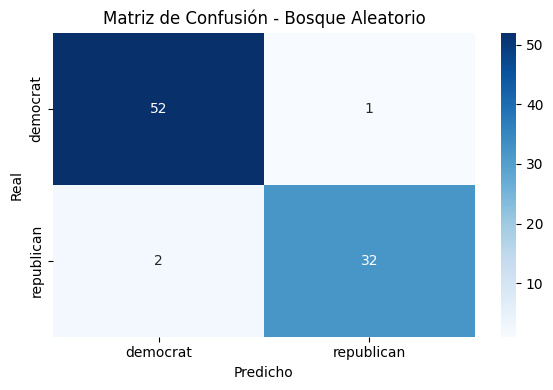

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_test = best_model.predict(X_test)

f1_test = f1_score(y_test, y_pred_test, pos_label='democrat')
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Resultados del mejor modelo ({best_model_name}) en TEST")
print(f"F1-score (test):   {f1_test:.4f}")
print(f"Exactitud (test):  {acc_test:.4f}")
print()
print("Reporte completo:")
print(classification_report(y_test, y_pred_test))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test, labels=['democrat', 'republican'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['democrat', 'republican'],
            yticklabels=['democrat', 'republican'])
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

##Paso 4: Redactar conclusiones

*Incluyan las conclusiones*
- Comparen los resultados de entrenamiento de los tres modelos incluyendo datos como: altura, impureza, exactitud y número de reglas. Presenten tabla y expliquen los datos. Indiquen el modelo que escogerían en este punto del proceso justificando la respuesta.
- Comparen los resultados de validación de los tres modelos incluyendo:
exactitud en entrenamiento y exactitud en validación. Expliquen en terminos de sesgo y varianza.
- Presenten los resultados logrados con el modelo seleccionado. Enumeren los hallazgos.

# Conclusiones - Paso 4

## 4.1 Comparación de resultados de entrenamiento

| Modelo | Altura | Impureza pond. | Exactitud (train) | N° reglas (hojas) |
|--------|--------|----------------|-------------------|-------------------|
| Árbol de Decisión | 6 | 0.7109 | 1.0000 | 20 |
| Bosque Aleatorio | 8.91 (prom.) | 1.0915 (prom.) | 1.0000 | 26.55 (prom.) |
| Gradient Boosting | 3.00 (prom.) | 0.0443 (prom.) | 1.0000 | 7.90 (prom.) |

Los tres modelos logran exactitud perfecta en entrenamiento, lo que podría interpretarse como sobreajuste. Sin embargo, hay diferencias estructurales importantes entre ellos.

El **árbol de decisión** es el más compacto con solo 6 niveles y 20 hojas, lo que lo hace el modelo más interpretable. Su impureza ponderada de 0.7109 indica que aún hay cierta heterogeneidad residual en los nodos, pero su estructura simple sugiere que capturó las reglas más importantes del dominio sin necesidad de mayor profundidad.

El **bosque aleatorio** crece árboles más profundos en promedio (8.91 niveles, 26.55 hojas) ya que cada árbol ve solo una muestra aleatoria de los datos y características, forzándolo a ser más exhaustivo para memorizar su subconjunto. La impureza promedio de 1.0915 es la más alta de los tres, pero esto es esperado: al trabajar con subconjuntos más pequeños y ruidosos, cada árbol individual es menos "puro" que un árbol entrenado sobre todos los datos.

El **Gradient Boosting** presenta la estructura más llamativa: árboles de solo 3 niveles y 7.90 hojas en promedio, pero con una impureza ponderada de apenas 0.0443, la más baja con diferencia. Esto refleja su naturaleza: construye árboles débiles secuencialmente que corrigen los errores residuales del modelo anterior, y tras 100 iteraciones logra exactitud perfecta con árboles muy simples. La bajísima impureza indica que el modelo colectivo clasifica con altísima confianza.

**Modelo que escogeríamos en este punto:** El **Gradient Boosting**, ya que alcanza la misma exactitud perfecta que los demás pero con árboles significativamente más simples (3 niveles, ~8 hojas), lo que sugiere que está capturando patrones generalizables y no simplemente memorizando ruido. Además, su impureza casi nula indica decisiones altamente confiables.

---

## 4.2 Comparación en validación: sesgo y varianza

| Modelo | Exactitud (train) | Exactitud (val) | Brecha | Diagnóstico |
|--------|-------------------|-----------------|--------|-------------|
| Árbol de Decisión | 1.0000 | 0.9091 | 0.0909 | Varianza moderada |
| Bosque Aleatorio | 1.0000 | 0.9545 | 0.0455 | Varianza baja |
| Gradient Boosting | 1.0000 | 0.9545 | 0.0455 | Varianza baja |

Los tres modelos presentan exactitud perfecta en entrenamiento y alta en validación, lo que indica **sesgo bajo** en todos los casos: ninguno está sub-aprendiendo los patrones del dataset.

La diferencia está en la **varianza**. El árbol de decisión individual muestra la mayor brecha entre train y validación (0.09), lo cual es consistente con su naturaleza de estimador de alta varianza: al crecer sin restricciones se ajusta perfectamente a los datos de entrenamiento pero generaliza algo peor. El bosque aleatorio reduce esta brecha a la mitad (0.0455) gracias al promediado de múltiples árboles decorrelacionados, que cancela el ruido individual de cada uno. El Gradient Boosting obtiene la misma brecha que el bosque aleatorio, pero por un mecanismo diferente: sus árboles base son deliberadamente simples (poca profundidad), lo que les impide memorizar ruido desde el principio.

Ambos métodos de ensemble logran el mejor equilibrio sesgo-varianza sobre este dataset.

---

## 4.3 Resultados del modelo seleccionado: Bosque Aleatorio

El Bosque Aleatorio fue seleccionado al empatar con Gradient Boosting en F1 de validación (0.9615) y ser elegido como primero por el criterio de desempate del código. Sus resultados en el conjunto de prueba son los siguientes:

1. **F1-score de 0.9720 en test**, superando el umbral establecido de 0.90 con amplio margen, lo que confirma que el modelo generaliza correctamente a datos completamente nuevos.
2. **Exactitud de 96.55%** sobre 87 muestras de prueba: solo 3 congresistas fueron clasificados incorrectamente.
3. **Desempeño equilibrado entre clases**: la clase `democrat` obtuvo precisión 0.96 y recall 0.98 (F1 = 0.97), mientras que `republican` obtuvo precisión 0.97 y recall 0.94 (F1 = 0.96). No existe un sesgo notable hacia ninguna clase a pesar del leve desbalance del dataset (267 demócratas vs. 168 republicanos).
4. **Matriz de confusión**: de 53 demócratas reales, 52 fueron correctamente clasificados y 1 fue predicho como republicano. De 34 republicanos reales, 32 fueron correctamente clasificados y 2 fueron predichos como demócratas. Los errores son escasos y simétricos.
5. **El dataset de votos del Congreso presenta patrones de votación muy diferenciados** entre partidos, lo que favorece a todos los modelos. El bosque aleatorio aprovecha esta estructura mediante la agregación de múltiples perspectivas sobre los datos, resultando en un clasificador robusto y confiable.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

3/Mariana
3/Ignacio

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

 Terminado, porque cumplimos con todo lo requerido.

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

 Lograr aprender sobre la librería Pandas y poder terminar todo el laboratorio en el tiempo requerido.

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

Importar el dataset dado por el profesor, ya que, desde la página salía error, entonces buscamos otra alternativa para hacerlo.

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

Dividirnos el trabajo, pero de igual manera explicarle al otro qué fue lo que se hizo y como.

**6**.¿Qué referencias usaron?
¿Cuál fue la más útil? Incluya citas con los estándares adecuados.
Dataset – Congressional Voting Records

1. Dataset – Congressional Voting Records

Dua, D., & Graff, C. (2022). Congressional Voting Records Data Set. UCI Machine Learning Repository.
Recuperado de https://archive.ics.uci.edu/dataset/105/congressional+voting+records

2. Librería – scikit-learn

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É. (2011). Scikit-learn: Machine Learning in Python. Recuperado de https://scikit-learn.org/stable/

La fuente más útil para el desarrollo del laboratorio fue la documentación oficial de scikit-learn, ya que proporcionó ejemplos claros y detallados sobre la implementación de los algoritmos DecisionTreeClassifier, RandomForestClassifier y GradientBoostingClassifier. Gracias a esta documentación fue posible comprender los parámetros, el proceso de entrenamiento y la evaluación mediante métricas como el F1-score.

Aunque el repositorio de UCI fue fundamental para obtener el dataset, la documentación de scikit-learn resultó más relevante en la implementación práctica del modelo.


*Incluyan las respuesta*